In [1]:
import os

def count_files_in_directories(root_dir):
    """
    Count the number of files in each directory within a specified root directory.
    :param root_dir: The root directory to start searching from.
    :return: A dictionary where the keys are the directory names and the values are the number of files in each directory.
    """
    file_counts = {}
    for dirpath, dirnames, filenames in os.walk(root_dir):
        file_counts[dirpath] = len(filenames)
    return file_counts


In [2]:
# root_dir = "/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data"
# file_counts = count_files_in_directories(root_dir)
# for directory, count in file_counts.items():
#     print(f"{directory}: {count} files")


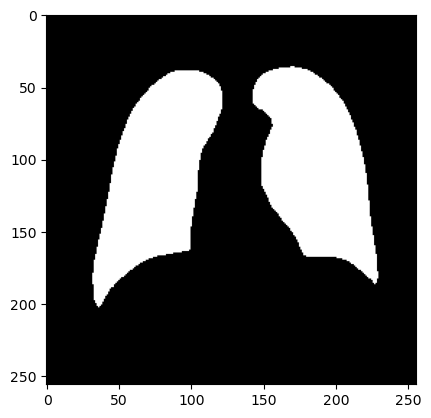

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/Normal/lung masks/Normal (10293).png")
plt.imshow(img)

In [4]:
import numpy as np
np.shape(img)

(256, 256, 3)

In [5]:
import numpy as np 
import tensorflow as tf
import pandas as pd
from tqdm import tqdm
import os

import cv2
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt

train_image_path = os.path.join("/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/Normal/images")
train_mask_path = os.path.join("/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Train/Normal/lung masks")
val_image_path = os.path.join("/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Val/Normal/images")
val_mask_path = os.path.join("/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Val/Normal/lung masks")
test_image_path = os.path.join("/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/Normal/images")
test_mask_path = os.path.join("/kaggle/input/covidqu/Lung Segmentation Data/Lung Segmentation Data/Test/Normal/lung masks")


In [6]:
def load_images_from_folder(folder_path, n):
    images = []
    count = 0
    for filename in tqdm(os.listdir(folder_path)):
        if filename.endswith('.png'):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path, 0)
            if img is not None:
                images.append(img.reshape((256, 256, 1)))
                count += 1
                if count >= n:
                    break
    return np.array(images)


In [7]:
train_lung_images = load_images_from_folder(train_image_path, 3000)
train_mask_images = load_images_from_folder(train_mask_path, 3000)
val_lung_images = load_images_from_folder(val_image_path, 200)
val_mask_images = load_images_from_folder(val_mask_path, 200)
test_lung_images = load_images_from_folder(test_image_path, 50)
test_mask_images = load_images_from_folder(test_mask_path, 50)
np.shape(train_lung_images)

  2%|▏         | 49/2140 [00:00<00:09, 226.79it/s]


(3000, 256, 256, 1)

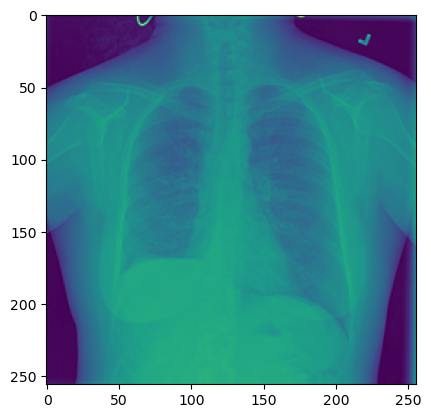

In [8]:
lung1 = train_lung_images[5]
mask1 = train_mask_images[5]
plt.imshow(lung1)

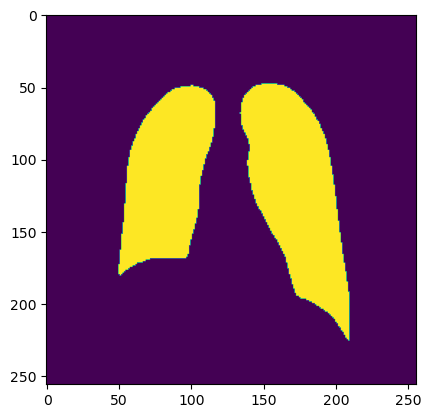

In [9]:
plt.imshow(mask1)

# UNET define

In [10]:
from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras import backend as keras
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout

def dice_coef(y_true, y_pred):
    y_true_f = keras.flatten(y_true)
    y_pred_f = keras.flatten(y_pred)
    intersection = keras.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1) / (keras.sum(y_true_f) + keras.sum(y_pred_f) + 1)

def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)


def jaccard_index(y_true, y_pred, smooth=1):
    intersection = keras.sum(keras.abs(y_true * y_pred), axis=-1)
    union = keras.sum(y_true, axis=-1) + keras.sum(y_pred, axis=-1) - intersection
    return (intersection + smooth) / (union + smooth)

def jaccard_loss(y_true, y_pred, smooth=1):
    return 1 - jaccard_index(y_true, y_pred)




def conv_block(input_tensor, num_filters):
    x = Conv2D(num_filters, 3, padding="same")(input_tensor)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.2)(x)  # Add dropout layer here

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.2)(x)  # Add dropout layer here

    return x



def encoder_block(input_tensor, num_filters):
    x = conv_block(input_tensor, num_filters)
    p = MaxPool2D((2, 2))(x)
    return x, p

def decoder_block(input_tensor, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input_tensor)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters)
    return x

def build_unet(input_shape):
    inputs = Input(input_shape)

    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    b1 = conv_block(p4, 512)

    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)
    #1-lung, 0-black area

    model = Model(inputs, outputs, name="U-Net")
    return model

input_shape = (256, 256, 1)
model = build_unet(input_shape)
model.compile(optimizer=Adam(learning_rate=1e-5), loss=dice_coef_loss,
                  metrics=[dice_coef, 'binary_accuracy', jaccard_index])
model.summary()

Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 32  320         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 256, 256, 32  128        ['conv2d[0][0]']                 
 alization)                     )                                                             

In [11]:
from keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
weight_path="{}_weights.best.hdf5".format('cxr_reg')

checkpoint = ModelCheckpoint(weight_path, monitor='val_loss', verbose=1, 
                             save_best_only=True, mode='min', save_weights_only = True)

reduceLROnPlat = ReduceLROnPlateau(monitor='val_loss', factor=0.5, 
                                   patience=10, 
                                   verbose=1, mode='min', epsilon=0.0001, cooldown=2, min_lr=1e-6)
early = EarlyStopping(monitor="val_loss", 
                      mode="min", 
                      patience=30) # probably needs to be more patient, but kaggle time is limited
callbacks_list = [checkpoint, early, reduceLROnPlat]

In [12]:
from sklearn.model_selection import train_test_split
import numpy as np

def normalize_and_convert_to_binary(lung_image, mask_image):
    # normalize the lung image
    lung_image_norm = (lung_image - 255.0) / 255.0

    # convert the mask image to binary
    mask_image_binary = (mask_image > 127).astype(np.float32)
    
    return lung_image_norm, mask_image_binary

# normalize and convert train data
train_lung_images_norm, train_mask_images_binary = normalize_and_convert_to_binary(train_lung_images, train_mask_images)

# normalize and convert validation data
val_lung_images_norm, val_mask_images_binary = normalize_and_convert_to_binary(val_lung_images, val_mask_images)


# fit the model
loss_history = model.fit(
    x=train_lung_images_norm,
    y=train_mask_images_binary,
    batch_size=16,
    epochs=100,
    validation_data=(val_lung_images_norm, val_mask_images_binary),
    callbacks=callbacks_list
)
model.save('/kaggle/working/unet_lung_mask_model')

Epoch 1/100


2023-04-04 19:02:54.472127: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inU-Net/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


188/188 [==============================] - ETA: 0s - loss: -0.4325 - dice_coef: 0.4328 - binary_accuracy: 0.5346 - jaccard_index: 0.7150
Epoch 1: val_loss improved from inf to -0.39932, saving model to cxr_reg_weights.best.hdf5
188/188 [==============================] - 58s 260ms/step - loss: -0.4325 - dice_coef: 0.4328 - binary_accuracy: 0.5346 - jaccard_index: 0.7150 - val_loss: -0.3993 - val_dice_coef: 0.3997 - val_binary_accuracy: 0.2476 - val_jaccard_index: 0.6599 - lr: 1.0000e-05
Epoch 2/100
188/188 [==============================] - ETA: 0s - loss: -0.5984 - dice_coef: 0.5986 - binary_accuracy: 0.8079 - jaccard_index: 0.7928
Epoch 2: val_loss improved from -0.39932 to -0.49178, saving model to cxr_reg_weights.best.hdf5
188/188 [==============================] - 46s 246ms/step - loss: -0.5984 - dice_coef: 0.5986 - binary_accuracy: 0.8079 - jaccard_index: 0.7928 - val_loss: -0.4918 - val_dice_coef: 0.4925 - val_binary_accuracy: 0.6302 - val_jaccard_index: 0.7256 - lr: 1.0000e-05
E

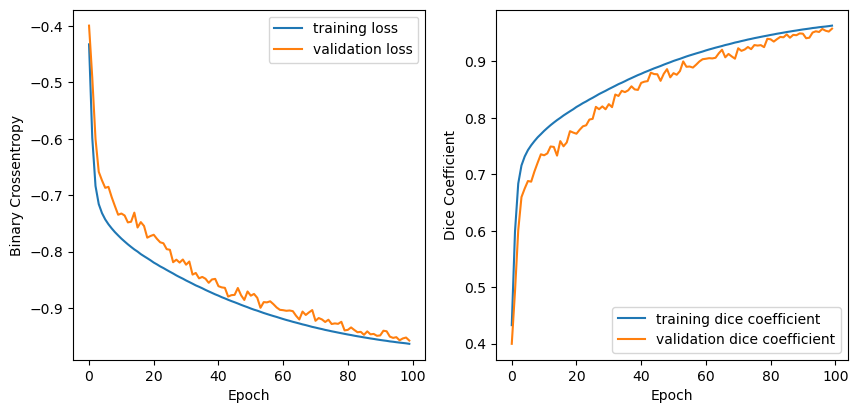

In [13]:
def get_metrics(history, loss):
    fig = plt.figure(figsize=(10,10))
    plt.subplot(2,2,1)
    plt.plot(history.history["loss"], label="training loss")
    plt.plot(history.history["val_loss"], label="validation loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Binary Crossentropy")

    if loss == "dice":
        plt.subplot(2,2,2)
        plt.plot(history.history["dice_coef"], label="training dice coefficient")
        plt.plot(history.history["val_dice_coef"], label="validation dice coefficient")
        plt.legend()
        plt.xlabel("Epoch")
        plt.ylabel("Dice Coefficient")
    elif loss == "jaccard":
        plt.subplot(2,2,2)
        plt.plot(history.history["jaccard_index"], label="training jaccard index")
        plt.plot(history.history["val_jaccard_index"], label="validation jaccard index")
        plt.legend()
        plt.xlabel("Epoch")
        plt.ylabel("Jaccard Index")
    else:
        print("Invalid loss function selected.")

get_metrics(history=loss_history, loss="dice")


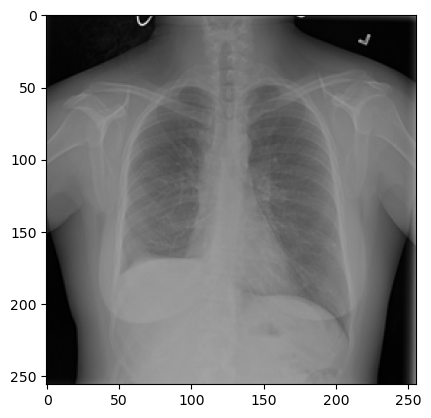

In [14]:
plt.imshow(train_lung_images_norm[5], cmap="gray")

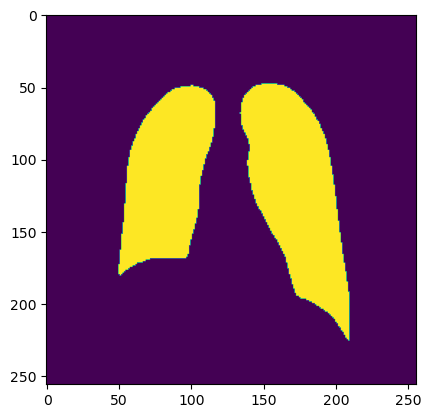

In [15]:
plt.imshow(train_mask_images_binary[5])

In [16]:
test_lung_images_norm, test_mask_images_binary = normalize_and_convert_to_binary(test_lung_images, test_mask_images)

predict_masks= model.predict(test_lung_images_norm)

2/2 [==============================] - 2s 792ms/step


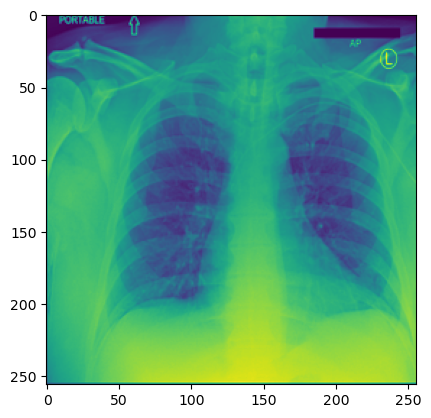

In [17]:
plt.imshow(test_lung_images_norm[7])

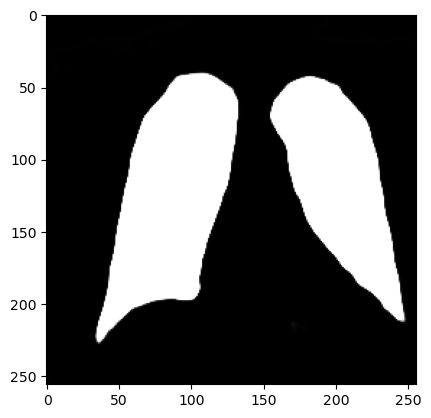

In [18]:
plt.imshow(predict_masks[7],cmap="gray")

In [19]:
np.unique(predict_masks)

array([0.00539569, 0.00559962, 0.00567887, ..., 0.9999989 , 0.99999905,
       0.9999993 ], dtype=float32)